In [ ]:
# from aso_workflow.pipeline import ASOAssessmentPipeline

# pipeline = ASOAssessmentPipeline(model_name="claude-sonnet-4-6", llm_only=True, use_web_search=True)
# hgvs = "NM_000350.3:c.2626C>T"
# result = pipeline.run(hgvs, steps_to_run=["variant_check"])
# result

In [ ]:
import json
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from scripts.evaluate import (
    parse_outcome_str, NEG_LABELS, POS_LABELS, NEUTRAL_LABELS
)

In [2]:
CATEGORIES = [
    "splice_correction",
    "exon_skipping",
    "transcript_knockdown",
    "wt_upregulation",
]

LABEL_ORDER = [
    "unable_to_assess",
    "not_eligible",
    "unlikely_eligible",
    "applicable",  # only for WT upregulation
    "likely_eligible",
    "eligible",
]

def categorize_assessment(row: pd.Series):
    labels = [row[k] for k in ["splice_correction", "exon_skipping", "transcript_knockdown", "wt_upregulation"]]
    if any([lbl in POS_LABELS for lbl in labels]):
        return "positive"
    elif any([lbl in NEUTRAL_LABELS for lbl in labels]):
        return "neutral"
    elif any([lbl in NEG_LABELS for lbl in labels]):
        return "negative"
    return "unable_to_assess"


dataset = pd.read_csv("data/parsed_n1c_assessments.csv")
dataset.drop_duplicates(subset="normalized_hgvs", keep="first", inplace=True)
parsed_outcomes = dataset["parsed_outcome"].apply(lambda x: parse_outcome_str(x)).tolist()

HGVS2OUTCOME = dict(zip(dataset["normalized_hgvs"], parsed_outcomes))
HGVS2METADATA = dataset.set_index("normalized_hgvs").drop(columns="parsed_outcome").to_dict(orient="index")

<Axes: ylabel='source'>

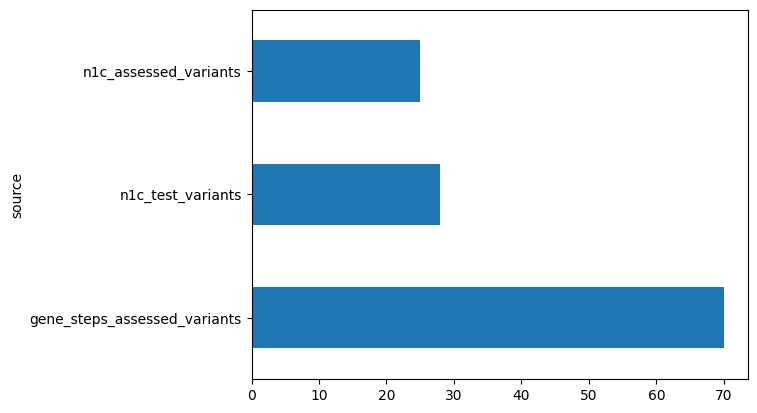

In [3]:
dataset['source'].value_counts().plot(kind='barh')

### dataset

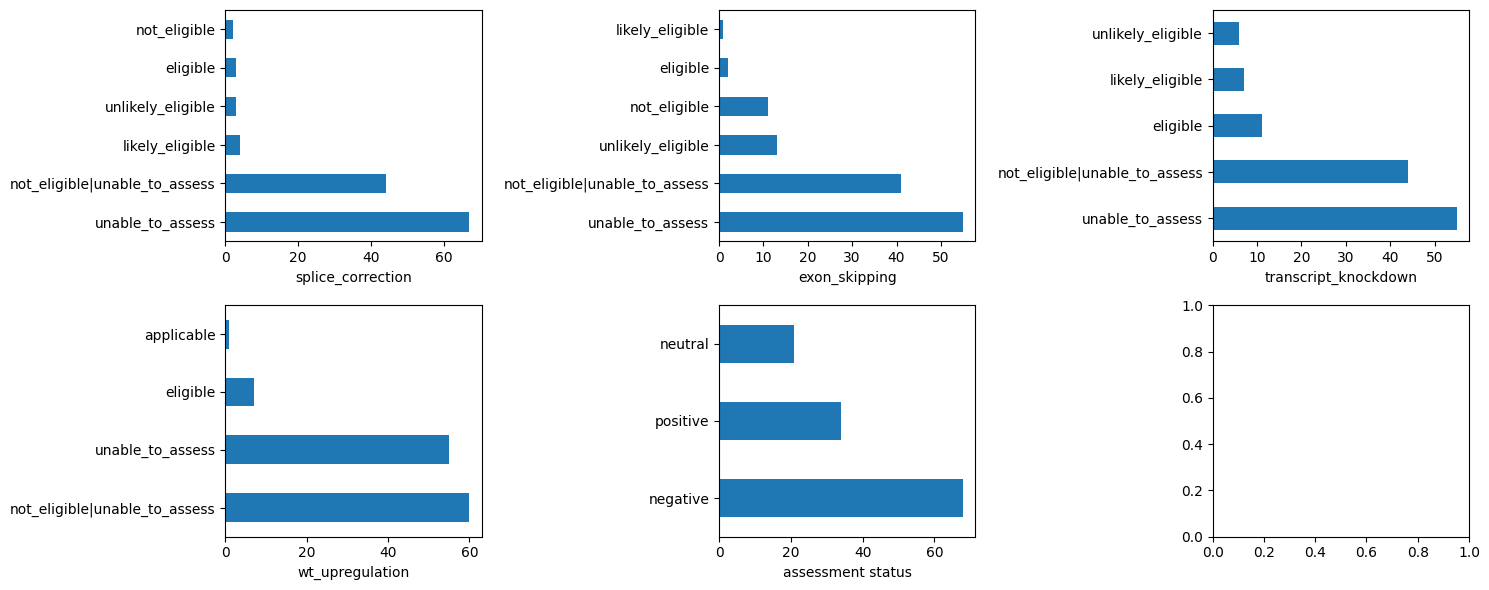

In [4]:
parsed_outcomes = dataset["parsed_outcome"].apply(lambda x: parse_outcome_str(x)).tolist()

fig, axs = plt.subplots(2, 3, figsize=(15, 6))
true_outcomes_df = pd.DataFrame(parsed_outcomes)
true_outcomes_df["assessment status"] = true_outcomes_df.apply(categorize_assessment, axis=1)

for col,ax in zip(true_outcomes_df.columns, axs.flatten()):
    true_outcomes_df[col].value_counts().plot(kind='barh', ax=ax)
    ax.set_ylabel("")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### report grading

In [146]:
class ReportsGrader:
    def __init__(self, out_dir: str):
        self.out_dir = out_dir
        self.results = []
        self.reports = None

        # load reports
        reports = []
        for fname in os.listdir(self.out_dir):
            if not fname.endswith(".json"):
                continue
            out_file = os.path.join(self.out_dir, fname)
            with open(out_file, "r") as f:
                report = json.load(f)
                reports.append(report)
        self.reports = reports
    
    def grade_category(self, category: str):
        if not category in ["pathomechanism", "inheritance", "splice_correction", "exon_skipping", "transcript_knockdown", "wt_upregulation"]:
            raise ValueError(f"Invalid category: {category}.\nPlease choose from: pathomechanism, inheritance, splice_correction, exon_skipping, transcript_knockdown, wt_upregulation")

        results = []
        for report in self.reports:
            hgvs, dataset = report["hgvs"], report["dataset"]
            if category in ["pathomechanism", "inheritance"]:
                true_ans = HGVS2METADATA[hgvs][category]
            else:
                true_ans = HGVS2OUTCOME[hgvs][category]
            
            if not isinstance(true_ans, str):
                # skip examples that have no label
                continue

            pred_ans, true_ans = ReportsGrader._normalize_labels(report, true_ans, category)
            results.append({"hgvs": hgvs, "dataset": dataset, "pred": pred_ans, "true": true_ans})

        results_df = pd.DataFrame(results)

        if category in ["pathomechanism", "inheritance"]:
            results_df["match"] = results_df["pred"] == results_df["true"]
        elif category in ["splice_correction", "exon_skipping", "transcript_knockdown", "wt_upregulation"]:
            results_df["match"] = results_df.apply(lambda row: row["pred"] in row["true"].split('|'), axis=1)
        
        return results_df
    
    @staticmethod
    def _normalize_labels(report: dict, true_ans: str, category: str, strict: bool = True):
        if category == "pathomechanism":
            label_map = {
                "loss_of_function": "lof",
                "gain_of_function": "gof",
                "dominant_negative": "dn",
            }
            if not report["pipeline_report"].get("context") or not report["pipeline_report"]["context"].get("pathomechanism"):
                return "unable_to_assess", true_ans
            pred_ans = report["pipeline_report"]["context"]["pathomechanism"]
            pred_ans = label_map.get(pred_ans, pred_ans)
            true_ans = true_ans.split(" ")[0].strip()
            return pred_ans, true_ans
        
        elif category == "inheritance":
            label_map = {
                "autosomal_dominant": "AD",
                "autosomal_recessive": "AR",
                "x_linked_dominant": "XDR",
                "x_linked_recessive": "XLR",
            }
            if not report["pipeline_report"].get("context") or not report["pipeline_report"]["context"].get("inheritance_pattern"):
                return "unable_to_assess", true_ans
            pred_ans = report["pipeline_report"]["context"]["inheritance_pattern"].lower()
            pred_ans = label_map.get(pred_ans, pred_ans)
            return pred_ans, true_ans
        
        elif category in ["splice_correction", "exon_skipping", "transcript_knockdown", "wt_upregulation"]:
            label_map = {"not_applicable": "not_eligible"}
            pred_ans = report["predicted_outcome"][category]
            pred_ans = label_map.get(pred_ans, pred_ans)

            if not strict:
                label_map = {k: "positive" for k in POS_LABELS}
                label_map.update({k: "negative" for k in NEG_LABELS})
                label_map.update({k: "neutral" for k in NEUTRAL_LABELS})
                pred_ans = label_map.get(pred_ans, pred_ans)
                true_ans = label_map.get(true_ans, true_ans)

            return pred_ans, true_ans
            
        else:
            raise ValueError(f"Invalid category: {category}")


def plot_cm(results_df: pd.DataFrame, ax: plt.Axes = None):
    # handle cases w multiple possible answers
    plot_df = results_df.copy()
    plot_df.loc[plot_df["match"], "true"] = plot_df.loc[plot_df["match"], "pred"]
    plot_df.loc[~plot_df["match"], "true"] = plot_df.loc[~plot_df["match"]].apply(lambda row: row["true"].split("|")[0], axis=1)

    # merge 'unknown' and 'unable_to_assess'
    for col in ["true", "pred"]:
        plot_df[col] = plot_df[col].apply(lambda x: "unknown" if x=="unable_to_assess" else x)

    # get all labels appearing in either column
    labels = sorted(
        set(plot_df["true"]).union(plot_df["pred"])
    )

    # Compute confusion matrix
    cm = confusion_matrix(
        y_true=plot_df["true"],
        y_pred=plot_df["pred"],
        labels=labels
    )
    # normalize rows
    cm_norm = cm.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    np.divide(
        cm,
        row_sums,
        out=cm_norm,
        where=row_sums != 0,
    )

    # plot
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    sns.heatmap(
        cm_norm,
        annot=cm,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False,
        linewidths=0.5,
        vmin=0,
        vmax=1,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=45)
    if ax is None:
        plt.show()

def get_token_stats(out_dir: str):
    token_stats = []
    for fname in os.listdir(out_dir):
        if not fname.endswith(".json"):
            continue
        out_file = os.path.join(out_dir, fname)
        with open(out_file, "r") as f:
            report = json.load(f)
        for model, usage in report["pipeline_report"]["total_token_usage"].items():
            token_stats.append({"model_name": model, **usage})
    return pd.DataFrame(token_stats)

Accuracy for pathomechanism: 0.627906976744186
Accuracy for inheritance: 0.9074074074074074
Accuracy for splice_correction: 0.873015873015873
Accuracy for exon_skipping: 0.6190476190476191
Accuracy for transcript_knockdown: 0.6507936507936508
Accuracy for wt_upregulation: 0.7301587301587301


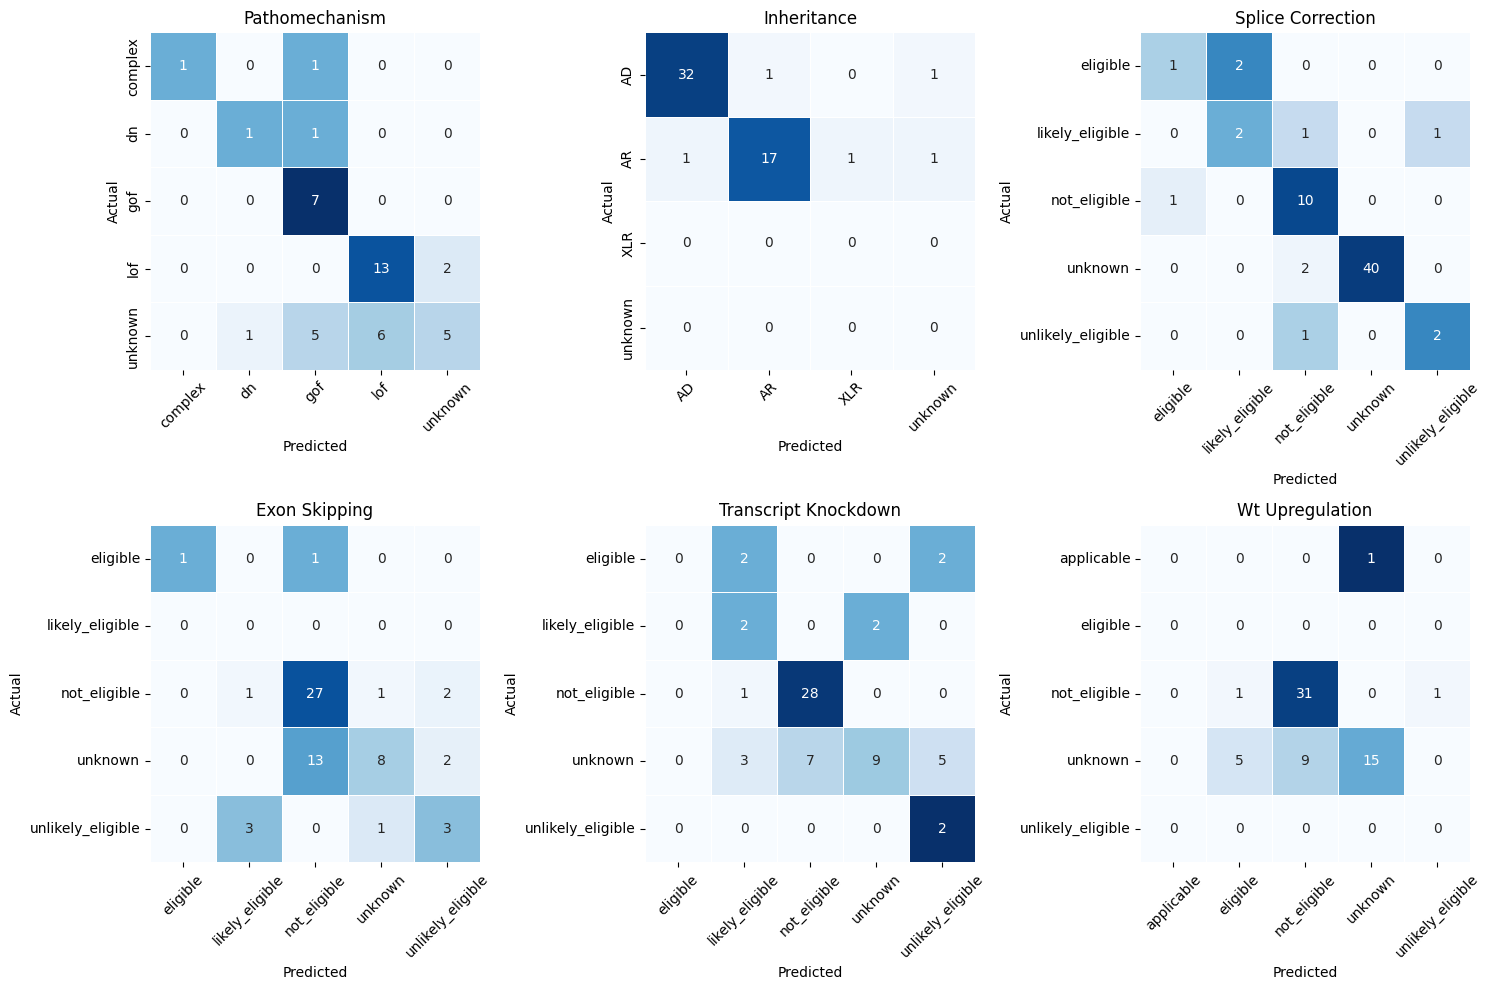

In [147]:
out_dir = "outputs/claude-sonnet-4-6"
grader = ReportsGrader(out_dir)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
categories = ["pathomechanism", "inheritance", "splice_correction", "exon_skipping", "transcript_knockdown", "wt_upregulation"]
for i, ax in enumerate(axs.flatten()):
    results_df = grader.grade_category(categories[i])
    print(f"Accuracy for {categories[i]}: {results_df['match'].mean()}")
    plot_cm(results_df, ax)
    ax.set_title(categories[i].replace("_", " ").title())

plt.tight_layout()
plt.show()

### cost comparison

In [11]:
token_stats = get_token_stats("outputs/claude-sonnet-4-6")
token_stats_avg = token_stats.groupby("model_name").mean()

cost1 = token_stats_avg.loc["claude-sonnet-4-6"]["input_tokens"] * 1.25/1e6 + token_stats_avg.loc["claude-sonnet-4-6"]["output_tokens"] * 10/1e6
cost2 = token_stats_avg.loc["gpt-5-nano"]["input_tokens"] * 0.05/1e6 + token_stats_avg.loc["gpt-5-nano"]["output_tokens"] * 0.40/1e6
print(cost1 + cost2)

0.26430715046031744
